In [180]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [181]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


from xgboost import XGBRegressor
import lightgbm as lgb

In [182]:
# Machine Leraning Classify
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [183]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns)} columns, {len(df_original)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [184]:
df_original

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [185]:
df_original[['Realm']].value_counts()

Realm                     
Central Indo-Pacific          5420
Tropical Atlantic             1915
Western Indo-Pacific          1264
Eastern Indo-Pacific           670
Temperate Australasia          266
Temperate Northern Pacific     113
Tropical Eastern Pacific        17
Name: count, dtype: int64

In [186]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original)+ 1} rows")

total number of rows and columns in the dataset: 49 columns, 9666 rows


In [187]:
## Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [188]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [189]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print(">>>>>>>  Missing values more than 0.4% : Delete >>>>>>")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

In [190]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')

C:\Users\superuser\AppData\Local\Temp\ipykernel_27132\2872477039.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_27132\2872477039.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


In [191]:
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

['Ocean', 'Realm', 'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town', 'City_Town_2', 'City_Town_3'] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 12 >>>>>>>> 37
total number of rows and columns in the dataset: 37 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


##

##

======================================
### Classify Box
======================================

In [192]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)

In [193]:
# data Classify from data Cleaning 
df_Classify_model = df_Clean_already.copy()

# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_Classify_model['Classify'] = (df_Classify_model['Percent_Bleaching'] >= 1).astype(int)
print(df_Classify_model[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_Classify_model.columns)}")


df_paperwraning = ['SSTA', 'ClimSST', 'Latitude_Degrees', 'Longitude_Degrees', 'SSTA_DHW', 'Year', 'Temperature_Kelvin']
feature_Classify = df_Classify_model[df_paperwraning]
target_Classify = df_Classify_model['Classify']

feature_Classify_values = feature_Classify.values
target_Classify_values = target_Classify.values



Classify
0           4513
1           1599
Name: count, dtype: int64
Original feature : 37 ---> become 38


In [194]:
df_Bleaching = df_Classify_model[df_Classify_model['Percent_Bleaching'] >= 1]

In [195]:
df_Bleaching.corr(method='pearson')['Percent_Bleaching'].sort_values(ascending=False)

Percent_Bleaching                        1.000000
SSTA_DHW                                 0.252629
SSTA_Frequency                           0.239021
TSA_DHW                                  0.236685
TSA_Frequency                            0.172556
SSTA                                     0.100311
Temperature_Kelvin                       0.086516
Latitude_Degrees                         0.085635
Temperature_Minimum                      0.082170
Temperature_Maximum                      0.081473
Temperature_Mean                         0.072091
TSA                                      0.069487
TSA_Minimum                              0.062305
SSTA_Minimum                             0.055283
TSA_Mean                                 0.043513
ClimSST                                  0.038218
Windspeed                                0.035082
SSTA_Frequency_Standard_Deviation        0.032212
TSA_Maximum                              0.031874
SSTA_Maximum                             0.025228


In [196]:
df_Bleaching.corr(method='spearman')['Percent_Bleaching'].sort_values(ascending=False)

Percent_Bleaching                        1.000000
SSTA_Frequency                           0.225977
TSA_Frequency                            0.213312
TSA_DHW                                  0.205150
SSTA_DHW                                 0.174441
Temperature_Kelvin                       0.115394
TSA                                      0.104336
Latitude_Degrees                         0.101396
SSTA                                     0.080256
Temperature_Mean                         0.079264
Year                                     0.073825
Temperature_Minimum                      0.060249
ClimSST                                  0.054694
Temperature_Maximum                      0.046776
TSA_Minimum                              0.046734
SSTA_Minimum                             0.018346
SSTA_Maximum                             0.018271
TSA_Mean                                 0.008483
SSTA_Standard_Deviation                  0.004536
SSTA_Frequency_Standard_Deviation        0.002548


In [197]:
feature_Classify

,SSTA,ClimSST,Latitude_Degrees,Longitude_Degrees,SSTA_DHW,Year,Temperature_Kelvin
0,1.320000,297.78,-20.899833,149.407722,3.960000,2016,301.670
1,1.320000,297.78,-20.893056,149.421000,3.960000,2016,301.670
2,0.870000,298.17,-20.745806,149.472056,2.680000,2016,301.380
3,1.070000,298.21,-20.737694,149.464944,3.650000,2016,301.560
4,1.760000,296.48,-20.259361,148.814583,3.840000,2017,296.380
...,...,...,...,...,...,...,...
9641,0.033333,262.15,20.738889,107.058333,2.378333,2003,302.955
9646,0.510000,299.80,20.845833,107.177778,0.000000,2003,302.300
9649,0.050000,301.40,12.601722,53.817306,0.000000,2008,302.670
9663,0.110000,304.39,15.701611,42.391806,2.250000,2008,303.890


In [198]:
target_Classify

0       1
1       1
2       1
3       1
4       1
       ..
9641    0
9646    0
9649    0
9663    0
9664    0
Name: Classify, Length: 6112, dtype: int32

In [ ]:
def set_datapretrain(X,y):
    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
    return X_train_class, X_test_class, y_train_class , y_test_class

X_train_classpaper , X_test_classpaper , y_train_classpaper , y_test_classpaper = set_datapretrain(feature_Classify,target_Classify)


def training_model(X_train, y_train, X_test, y_test):
    rf_class = RandomForestClassifier(n_estimators=300, 
                                      max_features='sqrt',
                                      max_depth=30,
                                      min_samples_split=5,
                                      min_samples_leaf=1,
                                      class_weight="balanced_subsample", 
                                      random_state=42)

    rf_class.fit(X_train, y_train)

    # Before (threshold = 0.50)
    y_pred_default = rf_class.predict(X_test)

    # After (threshold = 0.45)
    y_prob = rf_class.predict_proba(X_test)[:, 1]
    y_pred_adjusted = (y_prob >= 0.40).astype(int)

    print("=== Before (Threshold = 0.50) ===")
    print(classification_report(y_test, y_pred_default))

    print("=== After (Threshold = 0.40) ===")
    print(classification_report(y_test, y_pred_adjusted))

    print(f"AUC: {(roc_auc_score(y_test, y_prob)):.3f}")  # AUC ไม่เปลี่ยน
    
    return rf_class, y_pred_adjusted , y_pred_default
    
rf_class, y_pred_prob , y_pred_default = training_model(X_train_classpaper, y_train_classpaper, X_test_classpaper, y_test_classpaper)

=== Before (Threshold = 0.50) ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       891
           1       0.67      0.58      0.62       332

    accuracy                           0.81      1223
   macro avg       0.76      0.74      0.75      1223
weighted avg       0.80      0.81      0.80      1223

=== After (Threshold = 0.40) ===
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       891
           1       0.62      0.65      0.64       332

    accuracy                           0.80      1223
   macro avg       0.75      0.75      0.75      1223
weighted avg       0.80      0.80      0.80      1223

AUC: 0.836


In [273]:
rf_class.predict_proba(X_test_classpaper)[:20]

array([[0.40362361, 0.59637639],
       [0.23807507, 0.76192493],
       [0.90716165, 0.09283835],
       [0.36770946, 0.63229054],
       [0.88256268, 0.11743732],
       [0.73344479, 0.26655521],
       [0.95049089, 0.04950911],
       [0.98625804, 0.01374196],
       [0.89583277, 0.10416723],
       [0.56254765, 0.43745235],
       [0.98273626, 0.01726374],
       [0.64051336, 0.35948664],
       [0.26294101, 0.73705899],
       [0.73968202, 0.26031798],
       [0.394472  , 0.605528  ],
       [0.44872848, 0.55127152],
       [0.79444827, 0.20555173],
       [0.65989668, 0.34010332],
       [0.9363461 , 0.0636539 ],
       [0.98040934, 0.01959066]])

ALL train data : 1223
Series([], Name: count, dtype: int64)


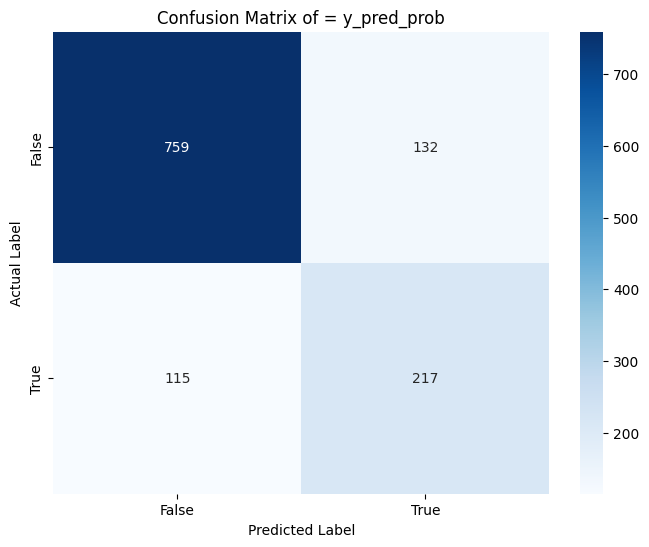

In [200]:
def plot_confusion_matrix(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix of = {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm
    
print(f"ALL train data : {len(y_test_classpaper)}")
print(f"{pd.DataFrame(y_test_classpaper, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_classpaper, y_pred_prob, ['False','True'], 'y_pred_prob')

ALL train data : 1223
Series([], Name: count, dtype: int64)


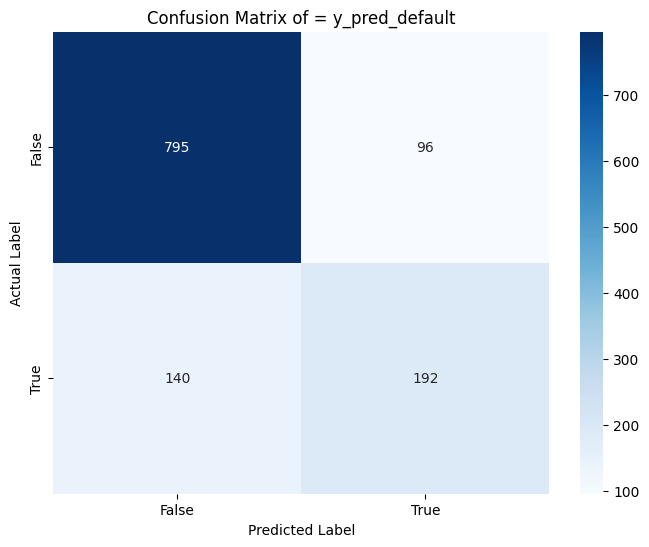

In [201]:
print(f"ALL train data : {len(y_test_classpaper)}")
print(f"{pd.DataFrame(y_test_classpaper, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_classpaper, y_pred_default, ['False','True'], 'y_pred_default')

In [202]:
feature_importance(rf_class,feature_Classify)

Columns have all : 7


,feature,importance
3,Longitude_Degrees,0.21
2,Latitude_Degrees,0.20
6,Temperature_Kelvin,0.14
1,ClimSST,0.12
0,SSTA,0.12
4,SSTA_DHW,0.11
5,Year,0.10


In [203]:
from sklearn.inspection import permutation_importance

# สร้าง scorer เฉพาะ Class 1
from sklearn.metrics import make_scorer, f1_score

scorer_class1 = make_scorer(f1_score, pos_label=1)

perm_imp = permutation_importance(
    rf_class, 
    X_test_classpaper, 
    y_test_classpaper,
    scoring   = scorer_class1,
    n_repeats = 30,
    random_state = 42,
    n_jobs = -1
)

# แสดงผล
perm_df = pd.DataFrame({
    'Feature'   : X_test_classpaper.columns,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print(perm_df)

              Feature  Importance       Std
3   Longitude_Degrees    0.296485  0.025420
2    Latitude_Degrees    0.176484  0.019365
5                Year    0.172992  0.018948
6  Temperature_Kelvin    0.097525  0.013660
1             ClimSST    0.078361  0.011657
4            SSTA_DHW    0.060634  0.014114
0                SSTA    0.049807  0.011575


from sklearn.model_selection import StratifiedKFold

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'max_features'     : [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : ['balanced', 'balanced_subsample']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1_weighted',  # เหมาะกับ Imbalanced data
    n_jobs     = -1,             # ใช้ทุก CPU
    verbose    = 2
)

grid_search.fit(X_train_classpaper, y_train_classpaper)

print(f"Best Params : {grid_search.best_params_}")
print(f"Best Score  : {grid_search.best_score_:.3f}")

##

===================================================================================
### กรณีที่เข้าโมเดล Classify เเล้ว ผลลัพธ์คือ เกิดรอดปะการังฟอกขาว หรือ Classify = 0
===================================================================================

In [204]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()

In [205]:
def Plotting_feature_target(df,col_feature, col_target='Percent_Bleaching'):
    
    X = df[col_feature]
    y = df[col_target]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolor='black', alpha=0.7)
    plt.xlabel(col_feature)
    plt.ylabel(col_target)
    plt.title(f'{col_feature} vs {col_target}')
    plt.show()

In [206]:
# แยกกลุ่ม < 1 และ >= 1
bleach_low  = df_Clean_already[df_Clean_already['Percent_Bleaching'] < 1]
bleach_high = df_Clean_already[df_Clean_already['Percent_Bleaching'] >= 1]

print(f"Bleaching < 1  : {len(bleach_low)}  ({len(bleach_low)/len(df_Clean_already)*100:.1f}%)")
print(f"Bleaching >= 1 : {len(bleach_high)} ({len(bleach_high)/len(df_Clean_already)*100:.1f}%)")

Bleaching < 1  : 4513  (73.8%)
Bleaching >= 1 : 1599 (26.2%)


In [207]:
# ดูว่า feature ไหนต่างกันมากระหว่าง 2 กลุ่ม
comparison = pd.DataFrame({
    'Bleach_low (<1)'  : bleach_low.mean(),
    'Bleach_high (>=1)': bleach_high.mean(),
})
comparison['difference'] = abs(comparison['Bleach_high (>=1)'] - comparison['Bleach_low (<1)'])
comparison.sort_values('difference', ascending=False)

,Bleach_low (<1),Bleach_high (>=1),difference
Longitude_Degrees,62.155289,47.688958,14.466331
Percent_Bleaching,0.055171,10.528702,10.473531
Latitude_Degrees,5.397115,1.994891,3.402224
ClimSST,293.284474,295.444622,2.160148
SSTA_FrequencyMax,25.088434,23.420027,1.668407
SSTA_DHWMax,19.939913,18.336473,1.603441
SSTA_DHW,2.936852,3.763181,0.826328
SSTA_Frequency,8.208845,8.988179,0.779335
TSA_DHW,0.899112,1.514770,0.615658
Year,2010.033237,2010.595372,0.562135


In [208]:
# ดู correlation เฉพาะในกลุ่มที่สนใจ
bleach_high.corr(method='spearman')['Percent_Bleaching'].sort_values(ascending=False)

Percent_Bleaching                        1.000000
SSTA_Frequency                           0.225977
TSA_Frequency                            0.213312
TSA_DHW                                  0.205150
SSTA_DHW                                 0.174441
Temperature_Kelvin                       0.115394
TSA                                      0.104336
Latitude_Degrees                         0.101396
SSTA                                     0.080256
Temperature_Mean                         0.079264
Year                                     0.073825
Temperature_Minimum                      0.060249
ClimSST                                  0.054694
Temperature_Maximum                      0.046776
TSA_Minimum                              0.046734
SSTA_Minimum                             0.018346
SSTA_Maximum                             0.018271
TSA_Mean                                 0.008483
SSTA_Standard_Deviation                  0.004536
SSTA_Frequency_Standard_Deviation        0.002548


In [209]:
bleach_high

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
0,-20.899833,149.407722,4.0,6.25,297.78,301.67,298.17,291.91,303.85,2.74,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,2016
1,-20.893056,149.421000,5.0,8.75,297.78,301.67,298.17,291.91,303.85,2.74,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,2016
2,-20.745806,149.472056,6.0,11.25,298.17,301.38,298.34,292.67,303.76,2.57,...,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49,2016
3,-20.737694,149.464944,5.0,25.00,298.21,301.56,298.37,292.01,304.04,2.52,...,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36,2016
4,-20.259361,148.814583,2.0,1.00,296.48,296.38,298.47,291.83,304.54,2.70,...,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9633,15.967500,108.445833,9.0,2.50,301.81,301.11,299.46,293.04,305.35,2.65,...,-3.12,2.0,1.67,7.0,1.0,0.00,1.28,9.05,0.48,2004
9635,15.972222,108.421667,3.0,1.50,301.70,301.08,299.42,292.99,304.98,2.62,...,-3.03,2.0,1.62,7.0,1.0,0.00,1.25,10.60,0.43,2004
9637,15.977222,108.500556,10.0,2.00,302.17,301.28,299.47,293.10,305.39,2.69,...,-3.19,2.0,1.71,7.0,1.0,0.00,1.33,8.75,0.53,2004
9638,15.979444,108.448611,5.0,4.50,302.19,302.10,299.46,293.04,305.35,2.65,...,-3.12,2.0,1.67,7.0,1.0,0.00,1.28,9.05,0.48,2004


##

##

-------------------------

===================================================================================
### กรณีที่เข้าโมเดล Classify เเล้ว ผลลัพธ์คือ เกิดปะการังฟอกขาว หรือ Classify == 1
===================================================================================

In [210]:
def PLOTING_RESULT_ML(model, X_test, y_test , cl, name):
    y_test = y_test.ravel()
    y_pred = model.predict(X_test)
    y_pred = y_pred.ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl,
        edgecolor='k'
    )

    # เส้น ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)):.2f}") # score from training
    pred = model.predict(X_test)
    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print(f"Test MSE: {test_mse:.2f}")
    print("-" * 30)


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse:.2f}")
    print("-" * 30)

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2:.2f}")
    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae:.2f}")
    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape:.2f}")
    print("-" * 30)
    
    print(pred.shape)
    print(y_test.shape)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#

def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#
    
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)


#--------------------------------------------------------------------------------------------------------------------------------------------#

def evaluate_model_ML(model, X_test, y_test): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    y_pred = y_pred.reshape(-1, 1).flatten()
    y_test = y_test.reshape(-1, 1).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)


In [211]:
df_reg = ['Latitude_Degrees', 'Longitude_Degrees','TSA_Frequency', 'SSTA_DHW', 'TSA_DHW', 'Year', 'SSTA_Frequency']
feature_reg = bleach_high[df_reg]
target_reg = bleach_high['Percent_Bleaching']

feature_reg_values = feature_reg.values
target_reg_values = target_reg.values


In [212]:
X_train_reg , X_test_reg , y_train_reg , y_test_reg = set_datapretrain(feature_reg_values,target_reg_values)

In [213]:
# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
model_xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # ใจเย็นๆ ค่อยๆ เดิน
    max_depth=4,          # ไม่ลึกเกินไปจนจำคำตอบ
    subsample=0.8,        # สุ่มข้อมูล
    colsample_bytree=0.8, # สุ่ม Feature
    reg_alpha=0.1,        # L1 Regularization
    reg_lambda=1.0,       # L2 Regularization
    random_state=42
)
# 2. เทรนโมเดล
weights = np.where(y_train_reg > 50, 2.0, 1.0)
model_xgb_reg.fit(X_train_reg, y_train_reg, sample_weight=weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [214]:
model_xgb_Claude = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,  # หยุดถ้าไม่ดีขึ้น 50 rounds
    random_state=42
)

model_xgb_Claude.fit(
    X_train_reg, y_train_reg,
    sample_weight=weights,
    eval_set=[(X_test_reg, y_test_reg)],
    verbose=200
)

print(f"Best iteration: {model_xgb_Claude.best_iteration}")

[0]	validation_0-rmse:18.10295
[200]	validation_0-rmse:13.98430
[400]	validation_0-rmse:13.30653
[600]	validation_0-rmse:13.07229
[800]	validation_0-rmse:12.95190
[984]	validation_0-rmse:12.91954
Best iteration: 934


In [215]:
Metric_result(model_xgb_Claude, X_train_reg, X_test_reg, y_train_reg, y_test_reg)

Score on training data: 0.75
------------------------------
Test MSE: 166.89
------------------------------
Test RMSE : 12.92
------------------------------
Test R2 Score : 0.49
------------------------------
Mean Absolute Error : 7.98
------------------------------
Mean Absolute Percentage Error : 2.33
------------------------------
(320,)
(320,)


In [216]:
Metric_result(model_xgb_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg)

Score on training data: 0.76
------------------------------
Test MSE: 166.79
------------------------------
Test RMSE : 12.91
------------------------------
Test R2 Score : 0.49
------------------------------
Mean Absolute Error : 7.98
------------------------------
Mean Absolute Percentage Error : 2.32
------------------------------
(320,)
(320,)


count    1599.000000
mean       10.528702
std        16.547607
min         1.000000
25%         1.750000
50%         4.250000
75%        10.000000
max       100.000000
Name: Percent_Bleaching, dtype: float64


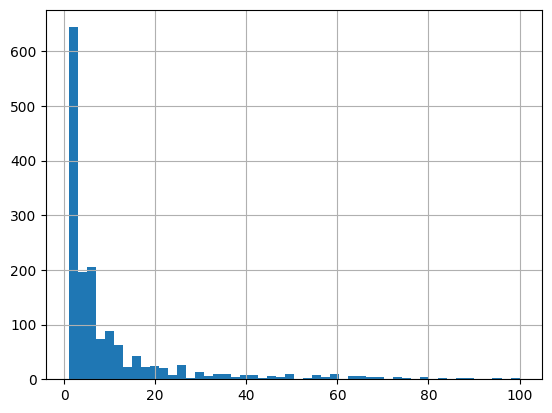

In [271]:
# ลอง print distribution เฉพาะกลุ่มที่เอามา regression
mask = bleach_high['Percent_Bleaching'] >= 1
print(bleach_high[mask]['Percent_Bleaching'].describe())
bleach_high[mask]['Percent_Bleaching'].hist(bins=50)
plt.show()

In [272]:
# Transform
y_train_log = np.log1p(y_train_reg)  # log(1 + y)

# Train บน log scale
model_xgb_reg.fit(X_train_reg, y_train_log)

# Predict แล้วแปลงกลับ
y_pred_log = model_xgb_reg.predict(X_test_reg)
y_pred = np.expm1(y_pred_log)  # แปลงกลับ

# วัดผลบน original scale
from sklearn.metrics import r2_score, mean_squared_error
print(f"R²: {r2_score(y_test_reg, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred)):.4f}")

R²: 0.4446
RMSE: 13.4234


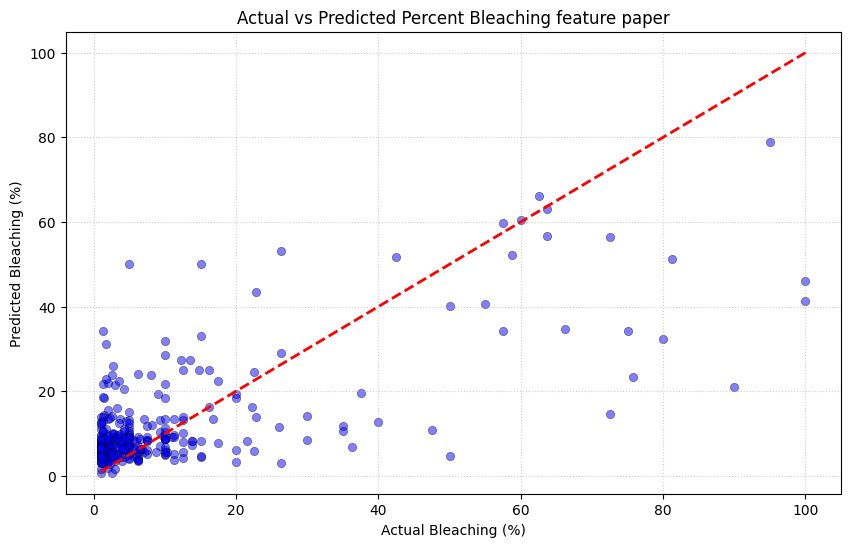

In [217]:
PLOTING_RESULT_ML(model_xgb_reg, X_test_reg, y_test_reg, 'blue', 'feature paper')

In [218]:
feature_importance(model_xgb_reg,feature_reg)

Columns have all : 7


,feature,importance
4,TSA_DHW,0.21
5,Year,0.17
1,Longitude_Degrees,0.14
6,SSTA_Frequency,0.13
3,SSTA_DHW,0.12
0,Latitude_Degrees,0.12
2,TSA_Frequency,0.11


##

===============================================================================
### principle Component Analysis  (PCA) + feature selected --> training model
===============================================================================

In [219]:
def Grouping_data(df, col_groupby, name_new_col, cols_keep=None):
    df_new = df.copy()
    df_new = df_new[col_groupby]
    print(f"Groupby name is : {name_new_col}")
    
    return df_new

In [220]:
df_reg

['Latitude_Degrees',
 'Longitude_Degrees',
 'TSA_Frequency',
 'SSTA_DHW',
 'TSA_DHW',
 'Year',
 'SSTA_Frequency']

In [221]:
col_SSTA = [#'SSTA', 
            #'SSTA_Mean', 
            'SSTA_Minimum', 
            'SSTA_Maximum', 
            'SSTA_Standard_Deviation',
            'SSTA_Frequency',
            'SSTA_Frequency_Standard_Deviation',
            'SSTA_FrequencyMax',
            'SSTA_FrequencyMean',
            #'SSTA_DHW',
            'SSTA_DHW_Standard_Deviation',
            'SSTA_DHWMax',
            'SSTA_DHWMean',
        ]
df_SSTA_groupby = Grouping_data(bleach_high, col_SSTA, 'SSTA_groupby')

Groupby name is : SSTA_groupby


In [222]:
col_temperature = [
                    'Temperature_Kelvin', 
                    'Temperature_Mean', 
                    'Temperature_Minimum', 
                    'Temperature_Maximum', 
                    'Temperature_Kelvin_Standard_Deviation'
                  ]
df_temperature_groupby = Grouping_data(bleach_high, col_temperature, 'temperature_groupby')

Groupby name is : temperature_groupby


In [223]:
col_TSA = [
           
           'TSA',
           'TSA_Standard_Deviation',
           'TSA_Minimum',
           'TSA_Maximum',
           'TSA_Mean',
           'TSA_Frequency',
           'TSA_Frequency_Standard_Deviation',
           'TSA_FrequencyMax',
           'TSA_FrequencyMean',
           #'TSA_DHW',
           'TSA_DHW_Standard_Deviation',
           'TSA_DHWMax',
           'TSA_DHWMean'
        ]
df_TSA_groupby = Grouping_data(bleach_high, col_TSA, 'TSA_groupby')

Groupby name is : TSA_groupby


In [224]:
print(f"Checking all columns : {len(col_SSTA) + len(col_temperature) + len(col_TSA)}")
print("คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้")

Checking all columns : 27
คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้


In [225]:
# Groupby data
def Groupby_values_data(df):
    return df.values

df_SSTA_values = Groupby_values_data(df_SSTA_groupby)
df_temperature_values = Groupby_values_data(df_temperature_groupby)
df_TSA_values = Groupby_values_data(df_TSA_groupby)

In [226]:
scaler = StandardScaler()
X_SSTAscalered = scaler.fit_transform(df_SSTA_values)
X_temperaturescalered = scaler.fit_transform(df_temperature_values)
X_TSAscalered = scaler.fit_transform(df_TSA_values)

In [227]:
def scree_plot(X, n_components, with_cumulative=False, show_data_label=False, figsize=(10, 7)):
    '''
    PCA scree plot with cumulative
    '''
    scaler = StandardScaler()
    X_t=scaler.fit_transform(X)

    max_components = min(X.shape)
    x=np.arange(1, n_components+1)
    pca = PCA(n_components=max_components)
    pca.fit_transform(X_t)
    y1=pca.explained_variance_ratio_[:n_components]
    y2=np.cumsum(pca.explained_variance_ratio_)[:n_components]
    
    plt.figure(figsize=figsize)
    
    if n_components > 20:
        marker = None
    else:
        marker = 'o'
    if with_cumulative:
        plt.plot(x, y2, linestyle='--', marker=marker, label='cumulative', color='salmon')
        
    plt.plot(x, y1, linestyle='-', marker=marker, label='individual', color='deepskyblue')
    plt.title('explained variance ratio')
    plt.xlabel('# of components')
    plt.ylabel('proportion of variance explained')
    plt.legend()
    if with_cumulative:
        [plt.axhline(y=xl, color='.7', linestyle='--') for xl in [.8, .9, .95, 1]]
    plt.grid(axis='x')

    if show_data_label:
        for n, v, cv in zip(np.nditer(x, flags=['refs_ok']), 
                            np.nditer(y1, flags=['refs_ok']),
                            np.nditer(y2, flags=['refs_ok'])):
                plt.text(n+.02, v+.02, f'{v*100:.2f}%', fontsize=10)
                if with_cumulative:
                    plt.text(n+.02, cv+.02, f'{cv*100:.2f}%', fontsize=10)

In [228]:
def discover_optimal_PCA_components(X, threshold= 0.95):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=X_scaled.shape[1])
    pca.fit_transform(X_scaled)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance >= threshold) + 1
    
    return optimal_components

In [229]:
optimal_n_components_SSTA = discover_optimal_PCA_components(X_SSTAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_SSTA}")

optimal_n_components_temp = discover_optimal_PCA_components(X_temperaturescalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_temp}")

optimal_n_components_TSA = discover_optimal_PCA_components(X_TSAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_TSA}")

Optimal number of PCA components to retain at least 95% vaeriance: 5
Optimal number of PCA components to retain at least 95% vaeriance: 3
Optimal number of PCA components to retain at least 95% vaeriance: 6


In [230]:
INPUT_X_PCA = [X_SSTAscalered,  X_temperaturescalered, X_TSAscalered]
N_COMPONENTS = [optimal_n_components_SSTA, optimal_n_components_temp, optimal_n_components_TSA]

In [231]:
def ALL_SCEEPLOT_AND_OTHERKEYWORD(input, n_components):
    pca = PCA(n_components= n_components)
    pca.fit_transform(input)
    print(f"Explained_variance (n_components = {pca.n_components}) = {pca.explained_variance_}") # Eigenvalues
    print("-" * 100)
    print(f"Explaned_variance_ratio (n_components = {pca.n_components}) = {pca.explained_variance_ratio_}") # Variance Ratio
    print("-" * 100)
    print(f"Total explained variance ratio: {np.sum(pca.explained_variance_ratio_).round(4)}")
    scree_plot(input, n_components, True, True)

📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: SSTA
Explained_variance (n_components = 5) = [5.95821096 1.25585953 0.9232873  0.81583765 0.61017211]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 5) = [0.59544847 0.12550741 0.09227099 0.08153274 0.06097905]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9557


📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: Temperature
Explained_variance (n_components = 3) = [3.38633945 1.15703052 0.37279165]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 3) = [0.67684433 0.23126139 0.0745117 ]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9826


📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: TSA
Explain

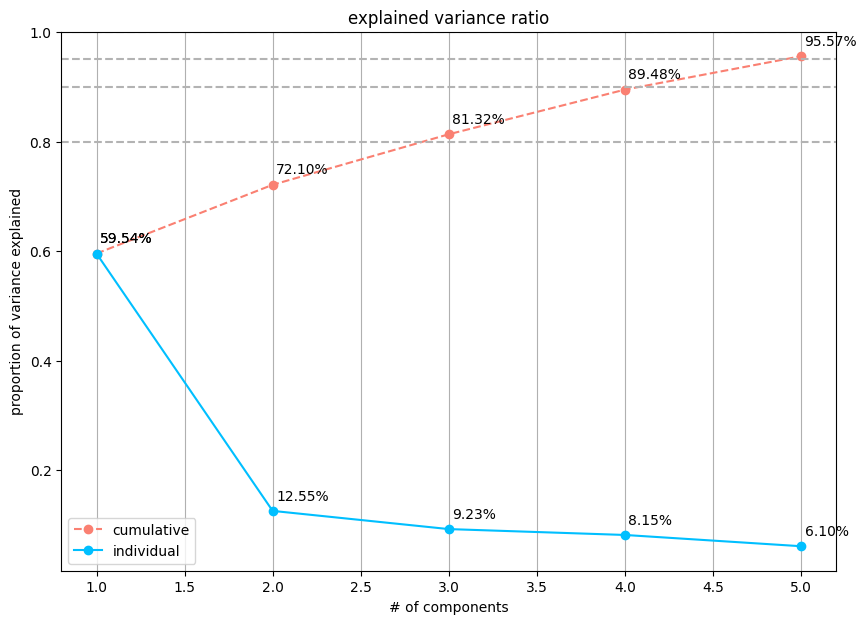

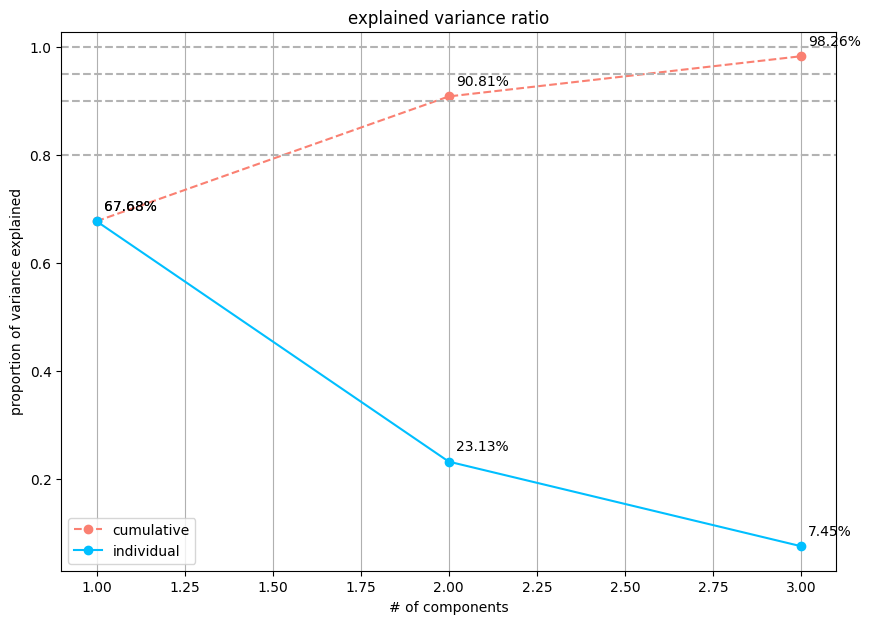

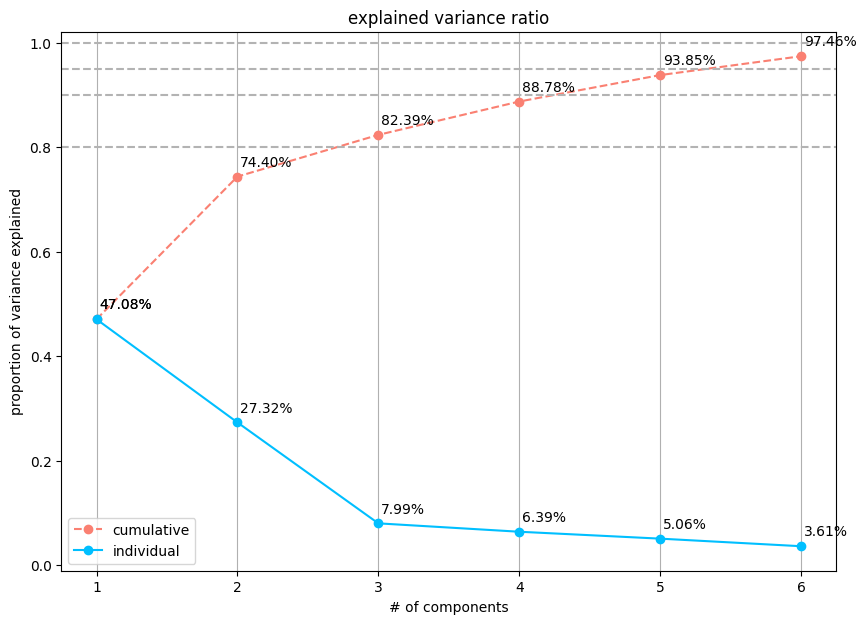

In [232]:
# 2. ตั้งชื่อชุดข้อมูลเพื่อให้ดูผลลัพธ์ง่ายขึ้น (เรียงตามลำดับข้อมูล)
DATASET_NAMES = ["SSTA", "Temperature", "TSA"]

# 3. วนลูปแล้วโยนเข้าฟังก์ชันของคุณ
for name, X_PCA, N_COM in zip(DATASET_NAMES, INPUT_X_PCA, N_COMPONENTS):
    print(f"📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: {name}")
    
    # เรียกใช้ฟังก์ชันที่คุณเขียนไว้
    ALL_SCEEPLOT_AND_OTHERKEYWORD(X_PCA, N_COM)
    
    print("\n") # เว้นบรรทัดยาวๆ คั่นก่อนเริ่มชุดข้อมูลต่อไป

In [233]:
pca_SSTA = PCA(n_components= optimal_n_components_SSTA)
pca_temp = PCA(n_components= optimal_n_components_temp)
pca_TSA = PCA(n_components= optimal_n_components_TSA)


pca_SSTA.fit_transform(X_SSTAscalered)
pca_temp.fit_transform(X_temperaturescalered)
pca_TSA.fit_transform(X_TSAscalered)

array([[-0.41648375,  2.3010621 , -0.4124777 ,  1.24865773, -1.13996013,
        -0.00858942],
       [-0.41648375,  2.3010621 , -0.4124777 ,  1.24865773, -1.13996013,
        -0.00858942],
       [-1.13669043,  1.96903021, -0.73865703,  0.86403654, -0.72589995,
        -0.53740173],
       ...,
       [-0.60900437,  2.64426968, -0.29142328,  0.32104962, -0.68775568,
        -0.02226744],
       [-0.57488424,  2.42524769, -0.34117369,  0.8174553 , -0.61811584,
        -0.12798907],
       [-0.57488424,  2.42524769, -0.34117369,  0.8174553 , -0.61811584,
        -0.12798907]])

In [234]:
X_SSTAscalered

array([[ 0.35338284, -0.51611402,  0.08077508, ...,  0.08409435,
         0.17424761,  0.15908905],
       [ 0.35338284, -0.51611402,  0.08077508, ...,  0.08409435,
         0.17424761,  0.15908905],
       [ 1.35126923, -0.73846856, -0.14765911, ...,  0.09046125,
         0.06926062, -0.00275405],
       ...,
       [-0.73819157,  0.27662826,  0.99451186, ...,  0.58071295,
         0.23859447,  1.0684931 ],
       [-1.09551333,  0.04460613,  0.90313818, ...,  0.41517342,
         0.21601663,  0.92206364],
       [-1.09551333,  0.04460613,  0.90313818, ...,  0.41517342,
         0.21601663,  0.92206364]])

In [235]:
dd_SSTA = pd.DataFrame(
    pca_SSTA.transform(X_SSTAscalered),
    columns=[f'PC_SSTA{n}' for n in range(1, pca_SSTA.n_components_ + 1)]
)
dd_SSTA.head()

,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5
0,0.494107,0.725240,0.634974,0.191932,-0.279397
1,0.494107,0.725240,0.634974,0.191932,-0.279397
2,-0.067490,1.129888,0.710717,1.145503,-0.276110
3,-0.190010,0.560500,0.177722,1.090946,0.187998
4,1.591611,1.294637,1.097166,-0.003845,-0.021636


In [236]:
dd_temp = pd.DataFrame(
    pca_temp.transform(X_temperaturescalered),
    columns=[f'PC_temp{n}' for n in range(1, pca_temp.n_components_ + 1)]
)
dd_temp.head()

,PC_temp1,PC_temp2,PC_temp3
0,-2.551899,0.609222,1.161769
1,-2.551899,0.609222,1.161769
2,-2.311198,0.309551,0.984351
3,-2.305317,0.530281,0.988283
4,-3.329264,0.264418,-1.105004


In [237]:
# ✅ วิธีมาตรฐาน
dd_TSA = pd.DataFrame(
    pca_TSA.transform(X_TSAscalered),
    columns=[f'PC_TSA{n}' for n in range(1, pca_TSA.n_components_ + 1)]
)

dd_TSA.head()

,PC_TSA1,PC_TSA2,PC_TSA3,PC_TSA4,PC_TSA5,PC_TSA6
0,-0.416484,2.301062,-0.412478,1.248658,-1.139960,-0.008589
1,-0.416484,2.301062,-0.412478,1.248658,-1.139960,-0.008589
2,-1.136690,1.969030,-0.738657,0.864037,-0.725900,-0.537402
3,-1.178173,2.073284,-0.859523,1.139667,-0.459353,-0.143493
4,-0.484577,3.451837,-0.193700,-1.779578,-0.790583,1.030868


In [238]:
dd_allpca = pd.concat([dd_SSTA, dd_temp, dd_TSA], axis=1)
dd_allpca

,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5,PC_temp1,PC_temp2,PC_temp3,PC_TSA1,PC_TSA2,PC_TSA3,PC_TSA4,PC_TSA5,PC_TSA6
0,0.494107,0.725240,0.634974,0.191932,-0.279397,-2.551899,0.609222,1.161769,-0.416484,2.301062,-0.412478,1.248658,-1.139960,-0.008589
1,0.494107,0.725240,0.634974,0.191932,-0.279397,-2.551899,0.609222,1.161769,-0.416484,2.301062,-0.412478,1.248658,-1.139960,-0.008589
2,-0.067490,1.129888,0.710717,1.145503,-0.276110,-2.311198,0.309551,0.984351,-1.136690,1.969030,-0.738657,0.864037,-0.725900,-0.537402
3,-0.190010,0.560500,0.177722,1.090946,0.187998,-2.305317,0.530281,0.988283,-1.178173,2.073284,-0.859523,1.139667,-0.459353,-0.143493
4,1.591611,1.294637,1.097166,-0.003845,-0.021636,-3.329264,0.264418,-1.105004,-0.484577,3.451837,-0.193700,-1.779578,-0.790583,1.030868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,1.753605,-0.315145,-0.492573,-0.467744,-1.113009,-1.643806,1.249642,0.179740,-0.631803,2.599727,-0.270193,0.264784,-0.630375,0.006973
1595,1.617934,-0.249826,-0.569321,-0.778320,-1.225016,-1.732571,1.013349,0.310230,-0.621974,2.446177,-0.284388,0.265836,-0.848718,-0.087072
1596,2.485232,0.485829,-0.500174,0.028126,-1.177410,-1.612985,1.320789,0.229496,-0.609004,2.644270,-0.291423,0.321050,-0.687756,-0.022267
1597,1.753605,-0.315145,-0.492573,-0.467744,-1.113009,-1.450756,1.386429,0.550793,-0.574884,2.425248,-0.341174,0.817455,-0.618116,-0.127989


In [239]:
print(f"columns original hvae : {len(bleach_high.columns)} ----> using pca of groupby have {len(dd_allpca.columns)}")

columns original hvae : 37 ----> using pca of groupby have 14


### Model PCA + feature selected

In [240]:
feature_selected = bleach_high[df_reg]
feature_pca = dd_allpca
target_pca_selected = bleach_high['Percent_Bleaching']

feature_selected_values = feature_selected.values
feature_pca_values = feature_pca.values
target_pca_selected_values = target_pca_selected.values

In [241]:
# Train/Test Split — ต้อง split พร้อมกัน
X_pca_train, X_pca_test, X_sel_train, X_sel_test, y_train_pca_sel, y_test_pca_sel = train_test_split(
    feature_pca_values, feature_selected_values, target_pca_selected_values,
    test_size=0.2,
    random_state=42
)

In [242]:
X_train_final = np.concatenate([X_pca_train, X_sel_train], axis=1)
X_test_final  = np.concatenate([X_pca_test,  X_sel_test],  axis=1)

In [243]:
model_xgb_reg_pca = model_xgb_reg
model_xgb_reg_pca.fit(X_train_final, y_train_pca_sel)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [244]:
Metric_result(model_xgb_reg_pca, X_train_final, X_test_final, y_train_pca_sel, y_test_pca_sel)

Score on training data: 0.81
------------------------------
Test MSE: 156.84
------------------------------
Test RMSE : 12.52
------------------------------
Test R2 Score : 0.52
------------------------------
Mean Absolute Error : 7.54
------------------------------
Mean Absolute Percentage Error : 2.11
------------------------------
(320,)
(320,)


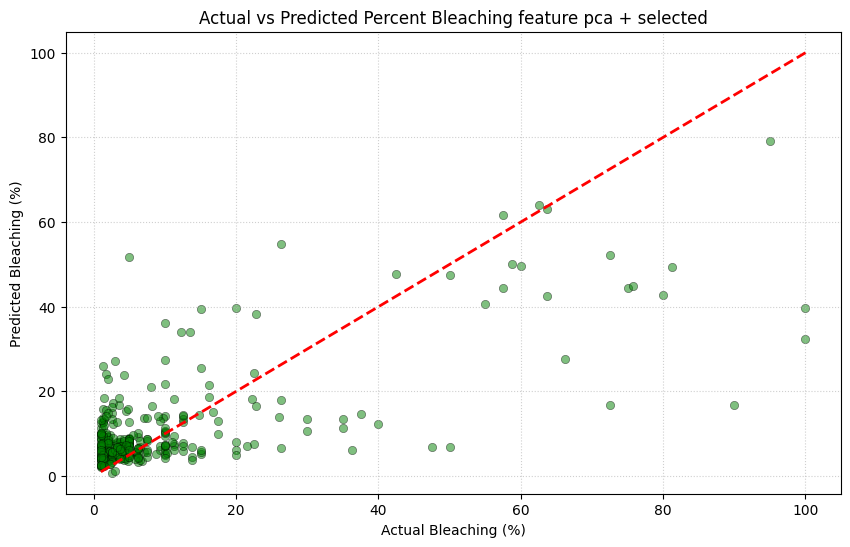

In [245]:
PLOTING_RESULT_ML(model_xgb_reg_pca, X_test_final, y_test_pca_sel, 'g', 'feature pca + selected')

In [246]:
pca_col_names      = dd_allpca.columns
selected_col_names = bleach_high[df_reg].columns

In [247]:
pca_col_names      = dd_allpca.columns.tolist()
selected_col_names = bleach_high[df_reg].columns.tolist()

# เช็คก่อนว่าจำนวนคอลัมน์ตรงกับ X_test_final
print(f"PCA cols      : {len(pca_col_names)}")
print(f"Selected cols : {len(selected_col_names)}")
print(f"รวม           : {len(pca_col_names) + len(selected_col_names)}")
print(f"X_test_final  : {X_test_final.shape[1]}")

X_test_df_pca_sel = pd.DataFrame(
    X_test_final,
    columns = pca_col_names + selected_col_names 
)

print(X_test_df_pca_sel.columns.tolist())
X_test_df_pca_sel.head()

PCA cols      : 14
Selected cols : 7
รวม           : 21
X_test_final  : 21
['PC_SSTA1', 'PC_SSTA2', 'PC_SSTA3', 'PC_SSTA4', 'PC_SSTA5', 'PC_temp1', 'PC_temp2', 'PC_temp3', 'PC_TSA1', 'PC_TSA2', 'PC_TSA3', 'PC_TSA4', 'PC_TSA5', 'PC_TSA6', 'Latitude_Degrees', 'Longitude_Degrees', 'TSA_Frequency', 'SSTA_DHW', 'TSA_DHW', 'Year', 'SSTA_Frequency']


,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5,PC_temp1,PC_temp2,PC_temp3,PC_TSA1,PC_TSA2,...,PC_TSA4,PC_TSA5,PC_TSA6,Latitude_Degrees,Longitude_Degrees,TSA_Frequency,SSTA_DHW,TSA_DHW,Year,SSTA_Frequency
0,1.078187,0.524535,0.366851,0.014953,-0.129732,1.358468,-0.060981,0.006767,0.701393,-1.343497,...,0.160042,-0.025153,0.535229,-8.348667,116.085806,5.0,11.39,6.57,2015.0,12.0
1,-0.628618,-0.891896,0.395586,-1.314697,-0.143794,1.753072,0.467019,0.366446,1.102583,-1.375164,...,0.785892,-0.287236,0.663895,6.506528,117.927528,6.0,4.99,3.70,2017.0,12.0
2,0.796346,0.789677,-1.484825,0.541036,-0.323415,-0.636345,0.618362,-0.096005,-0.842456,1.068781,...,0.304810,1.067192,-0.172122,-14.917000,145.689667,1.0,1.25,1.06,2004.0,1.0
3,-2.964055,-1.463522,0.635066,-0.257134,-0.015767,0.858121,-0.794218,0.318431,-1.760373,-1.449245,...,0.203808,0.387281,-0.361989,-16.549056,-151.703778,1.0,2.04,0.00,2016.0,8.0
4,2.056627,1.512670,0.381483,1.374600,0.817256,1.371853,0.734923,-0.547636,4.663340,-0.899982,...,0.025458,-0.124010,0.899832,10.289889,124.008472,7.0,0.00,0.00,2006.0,13.0


In [248]:
feature_importance(model_xgb_reg_pca, X_test_df_pca_sel)

Columns have all : 21


,feature,importance
18,TSA_DHW,0.10
19,Year,0.08
8,PC_TSA1,0.07
4,PC_SSTA5,0.06
15,Longitude_Degrees,0.06
12,PC_TSA5,0.06
20,SSTA_Frequency,0.06
17,SSTA_DHW,0.05
9,PC_TSA2,0.05
5,PC_temp1,0.05


##

##

==================================================================================================================
### fature Engineering  +  Principle Component Analysis (PCA)  + feature Selected  --->  training model
==================================================================================================================

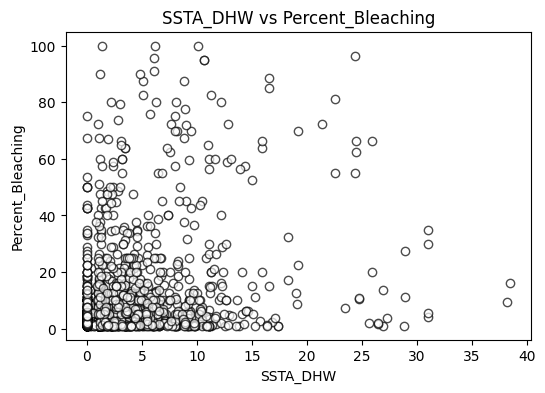

In [249]:
Plotting_feature_target(bleach_high,'SSTA_DHW')

In [250]:
print(len(bleach_high[bleach_high['SSTA_Frequency'] == 0]))
print(len(bleach_high[bleach_high['SSTA_DHW'] == 0]))

46
411


In [251]:
bleach_high[bleach_high['Percent_Bleaching'] < 5].describe()

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,0.899130,55.929294,6.807015,2.088460,295.372271,301.445526,300.323805,295.850734,304.968197,1.624705,...,-1.798079,2.162907,1.872335,8.528566,1.174866,1.087428,1.497385,10.880699,0.623972,2010.412604
std,16.462269,104.801974,3.559609,1.088816,13.486703,2.245071,1.737931,2.695752,1.368310,0.722045,...,1.040613,3.001628,0.726068,4.275259,2.153395,2.838550,1.290952,5.479736,1.197885,4.371965
min,-28.109167,-159.825000,0.100000,1.000000,262.150000,292.660000,294.710000,284.540000,301.500000,0.820000,...,-5.290000,0.000000,0.690000,3.000000,0.000000,0.000000,0.490000,2.590000,0.133333,2003.000000
25%,-16.534778,-66.015278,4.000000,1.000000,298.680000,300.380000,299.510000,293.940000,304.260000,1.140000,...,-2.680000,0.000000,1.380000,6.000000,0.000000,0.000000,1.000000,7.480000,0.300000,2006.000000
50%,5.229750,114.356500,6.000000,1.750000,300.720000,302.070000,300.870000,296.980000,305.200000,1.300000,...,-1.438000,1.000000,1.660000,7.000000,1.000000,0.000000,1.280000,9.860000,0.440000,2011.000000
75%,15.441500,145.690667,10.000000,2.750000,302.060000,302.970000,301.640000,297.750000,305.770000,2.110000,...,-1.110000,3.000000,2.170000,9.500000,1.000000,1.110000,1.680000,12.470000,0.650000,2014.000000
max,34.056111,179.943833,20.000000,4.750000,304.010000,305.290000,303.220000,299.880000,310.920000,4.260000,...,-0.010000,24.000000,5.490000,38.000000,20.000000,28.790000,13.930000,49.240000,12.660000,2017.000000


In [252]:
# ดู correlation เฉพาะในกลุ่มที่สนใจ
bleach_high.corr(method='spearman')['Percent_Bleaching'].sort_values(ascending=False)

Percent_Bleaching                        1.000000
SSTA_Frequency                           0.225977
TSA_Frequency                            0.213312
TSA_DHW                                  0.205150
SSTA_DHW                                 0.174441
Temperature_Kelvin                       0.115394
TSA                                      0.104336
Latitude_Degrees                         0.101396
SSTA                                     0.080256
Temperature_Mean                         0.079264
Year                                     0.073825
Temperature_Minimum                      0.060249
ClimSST                                  0.054694
Temperature_Maximum                      0.046776
TSA_Minimum                              0.046734
SSTA_Minimum                             0.018346
SSTA_Maximum                             0.018271
TSA_Mean                                 0.008483
SSTA_Standard_Deviation                  0.004536
SSTA_Frequency_Standard_Deviation        0.002548


In [253]:
# ดู rows ที่ bleaching สูงแต่ DHW ต่ำ
mask = (bleach_high['Percent_Bleaching'] >= 50) & (bleach_high['SSTA_DHW'] < 1)
print(bleach_high[mask][['Percent_Bleaching','SSTA_DHW','TSA_DHW',
                'Windspeed','Depth_m','SSTA']].to_string())

      Percent_Bleaching  SSTA_DHW  TSA_DHW  Windspeed  Depth_m   SSTA
1580              75.00       0.0      0.0        4.0      8.0  0.275
1679              53.75       0.0      0.0        6.0     10.0  0.140
2305              67.50       0.0      0.0        6.0      6.0  0.420
9219              50.00       0.0      0.0        4.0     10.0  0.450
9226              50.00       0.0      0.0        4.0     10.0  0.570
9233              50.00       0.0      0.0        4.0     10.0  0.550


In [254]:
# ดู rows ที่ bleaching สูงแต่ DHW ต่ำ
mask_less = ((bleach_high['Percent_Bleaching'] >= 0) & (bleach_high['Percent_Bleaching'] <= 20)) & (bleach_high['SSTA_DHW'] <= 1)
print(bleach_high[mask_less][['Percent_Bleaching','SSTA_DHW','TSA_DHW',
                'Windspeed','Depth_m','SSTA']].to_string())

      Percent_Bleaching  SSTA_DHW   TSA_DHW  Windspeed  Depth_m      SSTA
33               17.500  0.000000  0.000000        5.0      3.0  0.700000
35                3.500  0.000000  0.000000        8.0      3.0  0.840000
39                4.000  0.000000  0.000000        8.0     10.0  1.100000
46                3.500  0.000000  0.000000        8.0      3.0  1.100000
47                5.000  0.000000  0.000000        8.0     10.0  1.100000
50                1.000  0.000000  0.000000        8.0     10.0  0.940000
54                2.250  0.000000  0.000000        6.0      4.0  0.420000
119               5.250  0.000000  0.000000        7.0      7.0  0.310000
121              12.500  0.000000  0.000000        7.0      5.0  0.310000
126               1.000  0.000000  0.000000        7.0     11.0  0.690000
129               2.250  0.000000  0.000000        7.0      6.0  0.690000
131              12.500  0.000000  0.000000        7.0      4.0  0.060000
138               1.000  0.000000  0.0

In [255]:
# ดู rows ที่ bleaching สูงแต่ DHW ต่ำ
mask_meduim = ((bleach_high['Percent_Bleaching'] >= 5) & (bleach_high['Percent_Bleaching'] <= 10)) & (bleach_high['SSTA_DHW'] <= 1)
print(bleach_high[mask_meduim][['Percent_Bleaching','SSTA_DHW','TSA_DHW',
                'Windspeed','Depth_m','SSTA']].to_string())

      Percent_Bleaching  SSTA_DHW  TSA_DHW  Windspeed  Depth_m      SSTA
47                 5.00    0.0000      0.0        8.0     10.0  1.100000
119                5.25    0.0000      0.0        7.0      7.0  0.310000
153                6.50    0.0000      0.0        4.0      7.0  0.530000
161                5.00    0.0000      0.0        4.0      2.0  0.380000
165                5.00    0.0000      0.0        6.0      2.0  0.800000
167                5.00    0.0000      0.0        6.0      2.0  0.800000
169                5.25    0.0000      0.0        4.0      5.0  0.380000
175               10.00    0.0000      0.0        4.0      1.0  0.380000
495                5.75    0.7575      0.0        5.0     15.0  0.415000
734               10.00    0.0000      0.0        5.0      9.0  0.240000
735                6.25    0.0000      0.0        5.0      9.0  0.240000
747                6.25    1.0000      0.0        7.0     10.0  0.850000
761                6.25    0.0000      0.0        6

In [256]:
bleach_high[mask_less]

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
33,-18.956056,146.956250,3.0,17.5,299.09,299.77,299.05,293.35,304.85,2.58,...,-0.03,23.0,3.10,27.0,20.0,0.0,13.67,47.72,12.35,2016
35,-18.886667,-159.825000,3.0,3.5,298.72,299.38,299.88,295.82,304.05,1.26,...,-1.33,0.0,2.07,9.0,1.0,0.0,1.48,10.29,0.53,2005
39,-18.853333,-159.805000,10.0,4.0,298.68,299.60,299.87,295.82,303.92,1.29,...,-1.35,0.0,2.44,12.0,1.0,0.0,1.82,16.77,0.64,2005
46,-18.835000,-159.795000,3.0,3.5,298.68,299.60,299.87,295.82,303.92,1.29,...,-1.35,0.0,2.44,12.0,1.0,0.0,1.82,16.77,0.64,2005
47,-18.835000,-159.795000,10.0,5.0,298.68,299.60,299.87,295.82,303.92,1.29,...,-1.35,0.0,2.44,12.0,1.0,0.0,1.82,16.77,0.64,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9633,15.967500,108.445833,9.0,2.5,301.81,301.11,299.46,293.04,305.35,2.65,...,-3.12,2.0,1.67,7.0,1.0,0.0,1.28,9.05,0.48,2004
9635,15.972222,108.421667,3.0,1.5,301.70,301.08,299.42,292.99,304.98,2.62,...,-3.03,2.0,1.62,7.0,1.0,0.0,1.25,10.60,0.43,2004
9637,15.977222,108.500556,10.0,2.0,302.17,301.28,299.47,293.10,305.39,2.69,...,-3.19,2.0,1.71,7.0,1.0,0.0,1.33,8.75,0.53,2004
9638,15.979444,108.448611,5.0,4.5,302.19,302.10,299.46,293.04,305.35,2.65,...,-3.12,2.0,1.67,7.0,1.0,0.0,1.28,9.05,0.48,2004


In [257]:
bleach_high[mask_meduim]

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
47,-18.835000,-159.795000,10.0,5.00,298.68,299.60,299.87,295.820000,303.92,1.290,...,-1.350000,0.0,2.440000,12.000000,1.000000,0.0,1.820000,16.77,0.640000,2005
119,-27.396667,153.556944,7.0,5.25,297.34,295.60,296.92,292.010000,303.07,2.130,...,-2.820000,1.0,1.410000,6.000000,1.000000,0.0,1.080000,7.99,0.330000,2016
153,-23.460389,151.929194,7.0,6.50,297.07,295.50,297.33,292.220000,303.13,2.290,...,-3.020000,0.0,1.670000,6.000000,1.000000,0.0,1.360000,10.94,0.400000,2016
161,-23.444694,151.918389,2.0,5.00,297.05,295.37,297.35,292.830000,302.86,2.220,...,-2.910000,0.0,1.990000,7.000000,1.000000,0.0,1.530000,12.13,0.440000,2016
165,-23.443111,151.909389,2.0,5.00,297.41,296.04,297.35,292.830000,302.86,2.220,...,-2.910000,0.0,1.990000,7.000000,1.000000,0.0,1.530000,12.13,0.440000,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9190,21.830167,-72.172500,11.3,9.50,301.64,301.41,299.88,295.720000,304.29,1.510,...,-1.750000,3.0,1.040000,4.000000,1.000000,0.0,0.860000,4.40,0.340000,2007
9261,21.268444,-157.823778,1.7,7.50,297.32,297.83,298.46,294.640000,301.71,1.180,...,-1.470000,0.0,1.380000,8.000000,0.000000,0.0,0.950000,8.30,0.220000,2010
9315,25.140083,-80.259833,6.0,6.00,302.71,301.85,299.88,293.950000,305.64,2.270,...,-3.110000,0.0,0.910000,4.000000,0.000000,0.0,0.610000,4.92,0.180000,2005
9368,-17.738167,168.278000,10.0,5.00,262.15,302.20,299.92,295.835000,303.93,1.355,...,-1.590000,0.0,1.445000,7.000000,0.000000,0.0,0.980000,10.80,0.290000,2004


In [258]:
# ดู rows ที่ bleaching สูงแต่ DHW ต่ำ
mask = (bleach_high['Percent_Bleaching'] >= 50) & (bleach_high['Depth_m'] <= 1)
print(bleach_high[mask][['Percent_Bleaching','SSTA_DHW','TSA_DHW',
                'Windspeed','Depth_m','SSTA_Frequency']].to_string())

      Percent_Bleaching  SSTA_DHW  TSA_DHW  Windspeed  Depth_m  SSTA_Frequency
3578               50.0      2.97     2.88        3.0      1.0             4.0


In [259]:
# Feature Enggineering function 

def Feature_Engineering(df):
    # เพิ่ม threshold ที่ข้อมูลบอกว่ามีนัยสำคัญ
    df['DHW_Exceeds4']  = (df['SSTA_DHW'] >= 4).astype(int)
    df['DHW_Exceeds8']  = (df['SSTA_DHW'] >= 8).astype(int)
    df['DHW_Exceeds12'] = (df['SSTA_DHW'] >= 12).astype(int)  # เพิ่มตัวนี้
    
    col_fn = ['DHW_Exceeds4', 'DHW_Exceeds8', 'DHW_Exceeds12']
    
    return df , col_fn

In [260]:
bleach_pca_selected_featureengineering, col_fn = Feature_Engineering(bleach_high)

C:\Users\superuser\AppData\Local\Temp\ipykernel_27132\2464494469.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DHW_Exceeds4']  = (df['SSTA_DHW'] >= 4).astype(int)
C:\Users\superuser\AppData\Local\Temp\ipykernel_27132\2464494469.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DHW_Exceeds8']  = (df['SSTA_DHW'] >= 8).astype(int)
C:\Users\superuser\AppData\Local\Temp\ipykernel_27132\2464494469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [261]:
bleach_pca_selected_featureengineering

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year,DHW_Exceeds4,DHW_Exceeds8,DHW_Exceeds12
0,-20.899833,149.407722,4.0,6.25,297.78,301.67,298.17,291.91,303.85,2.74,...,7.0,1.0,3.52,1.36,8.43,0.52,2016,0,0,0
1,-20.893056,149.421000,5.0,8.75,297.78,301.67,298.17,291.91,303.85,2.74,...,7.0,1.0,3.52,1.36,8.43,0.52,2016,0,0,0
2,-20.745806,149.472056,6.0,11.25,298.17,301.38,298.34,292.67,303.76,2.57,...,5.0,1.0,1.51,1.23,7.32,0.49,2016,0,0,0
3,-20.737694,149.464944,5.0,25.00,298.21,301.56,298.37,292.01,304.04,2.52,...,5.0,1.0,2.36,0.97,6.86,0.36,2016,0,0,0
4,-20.259361,148.814583,2.0,1.00,296.48,296.38,298.47,291.83,304.54,2.70,...,7.0,1.0,0.00,1.47,9.84,0.56,2017,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9633,15.967500,108.445833,9.0,2.50,301.81,301.11,299.46,293.04,305.35,2.65,...,7.0,1.0,0.00,1.28,9.05,0.48,2004,0,0,0
9635,15.972222,108.421667,3.0,1.50,301.70,301.08,299.42,292.99,304.98,2.62,...,7.0,1.0,0.00,1.25,10.60,0.43,2004,0,0,0
9637,15.977222,108.500556,10.0,2.00,302.17,301.28,299.47,293.10,305.39,2.69,...,7.0,1.0,0.00,1.33,8.75,0.53,2004,0,0,0
9638,15.979444,108.448611,5.0,4.50,302.19,302.10,299.46,293.04,305.35,2.65,...,7.0,1.0,0.00,1.28,9.05,0.48,2004,0,0,0


In [262]:
feature_selected = bleach_pca_selected_featureengineering[df_reg]
feature_pca = dd_allpca
feature_feature_engineer = bleach_pca_selected_featureengineering[col_fn]
target_pca_sel_fn = bleach_pca_selected_featureengineering['Percent_Bleaching']

feature_selected_values = feature_selected.values
feature_pca_values = feature_pca.values
feature_featureeengineer_values = feature_feature_engineer.values
target_pca_sel_fn_values = target_pca_sel_fn.values

In [263]:
# Train/Test Split — ต้อง split พร้อมกัน
X_pca_train, X_pca_test, X_sel_train, X_sel_test,X_fn_train, X_fn_test, y_train_pca_sel_fn, y_test_pca_sel_fn = train_test_split(
    feature_pca_values, feature_selected_values, feature_featureeengineer_values, target_pca_selected_values,
    test_size=0.2,
    random_state=42
)

In [264]:
X_trainpcaselfn_final = np.concatenate([X_pca_train, X_sel_train, X_fn_train], axis=1)
X_testpcaselfn_final  = np.concatenate([X_pca_test,  X_sel_test, X_fn_test],  axis=1)

In [265]:
model_xgb_reg_pcaselfn = model_xgb_reg
model_xgb_reg_pcaselfn.fit(X_trainpcaselfn_final, y_train_pca_sel_fn)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [266]:
Metric_result(model_xgb_reg_pcaselfn, X_trainpcaselfn_final, X_testpcaselfn_final, y_train_pca_sel_fn, y_test_pca_sel_fn)

Score on training data: 0.81
------------------------------
Test MSE: 157.62
------------------------------
Test RMSE : 12.55
------------------------------
Test R2 Score : 0.51
------------------------------
Mean Absolute Error : 7.51
------------------------------
Mean Absolute Percentage Error : 2.10
------------------------------
(320,)
(320,)


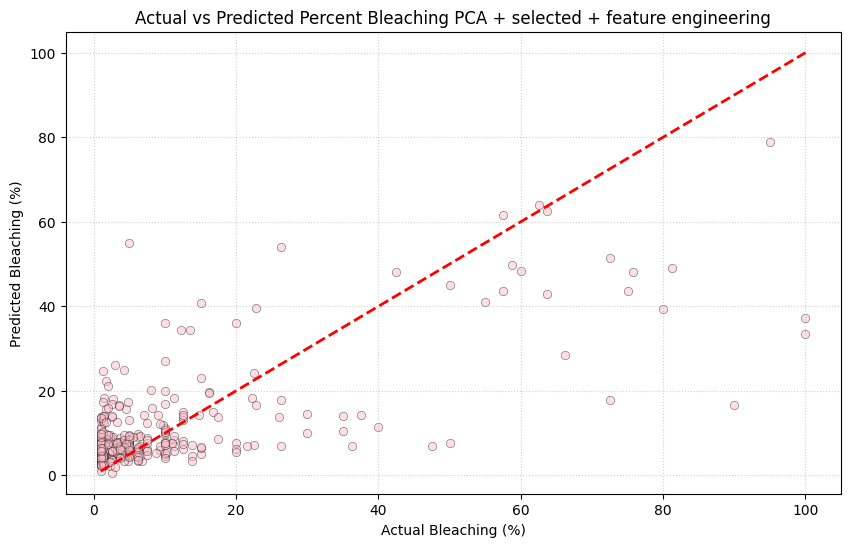

In [267]:
PLOTING_RESULT_ML(model_xgb_reg_pcaselfn,X_testpcaselfn_final,y_test_pca_sel_fn, 'pink', 'PCA + selected + feature engineering')

In [268]:
pca_col_names      = dd_allpca.columns.tolist()
selected_col_names = bleach_high[df_reg].columns.tolist()
featureEn_col_names = bleach_high[col_fn].columns.tolist()

# เช็คก่อนว่าจำนวนคอลัมน์ตรงกับ X_test_final
print(f"PCA cols      : {len(pca_col_names)}")
print(f"Selected cols : {len(selected_col_names)}")
print(f"FeatureEn cols : {len(featureEn_col_names)}")
print(f"รวม           : {len(pca_col_names) + len(selected_col_names) + len(featureEn_col_names)}")
print(f"X_test_final  : {X_test_final.shape[1]}")

X_test_df_pca_sel_fn = pd.DataFrame(
    X_testpcaselfn_final,
    columns = pca_col_names + selected_col_names + featureEn_col_names
)

print(X_test_df_pca_sel_fn.columns.tolist())
X_test_df_pca_sel_fn.head()

PCA cols      : 14
Selected cols : 7
FeatureEn cols : 3
รวม           : 24
X_test_final  : 21
['PC_SSTA1', 'PC_SSTA2', 'PC_SSTA3', 'PC_SSTA4', 'PC_SSTA5', 'PC_temp1', 'PC_temp2', 'PC_temp3', 'PC_TSA1', 'PC_TSA2', 'PC_TSA3', 'PC_TSA4', 'PC_TSA5', 'PC_TSA6', 'Latitude_Degrees', 'Longitude_Degrees', 'TSA_Frequency', 'SSTA_DHW', 'TSA_DHW', 'Year', 'SSTA_Frequency', 'DHW_Exceeds4', 'DHW_Exceeds8', 'DHW_Exceeds12']


,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5,PC_temp1,PC_temp2,PC_temp3,PC_TSA1,PC_TSA2,...,Latitude_Degrees,Longitude_Degrees,TSA_Frequency,SSTA_DHW,TSA_DHW,Year,SSTA_Frequency,DHW_Exceeds4,DHW_Exceeds8,DHW_Exceeds12
0,1.078187,0.524535,0.366851,0.014953,-0.129732,1.358468,-0.060981,0.006767,0.701393,-1.343497,...,-8.348667,116.085806,5.0,11.39,6.57,2015.0,12.0,1.0,1.0,0.0
1,-0.628618,-0.891896,0.395586,-1.314697,-0.143794,1.753072,0.467019,0.366446,1.102583,-1.375164,...,6.506528,117.927528,6.0,4.99,3.70,2017.0,12.0,1.0,0.0,0.0
2,0.796346,0.789677,-1.484825,0.541036,-0.323415,-0.636345,0.618362,-0.096005,-0.842456,1.068781,...,-14.917000,145.689667,1.0,1.25,1.06,2004.0,1.0,0.0,0.0,0.0
3,-2.964055,-1.463522,0.635066,-0.257134,-0.015767,0.858121,-0.794218,0.318431,-1.760373,-1.449245,...,-16.549056,-151.703778,1.0,2.04,0.00,2016.0,8.0,0.0,0.0,0.0
4,2.056627,1.512670,0.381483,1.374600,0.817256,1.371853,0.734923,-0.547636,4.663340,-0.899982,...,10.289889,124.008472,7.0,0.00,0.00,2006.0,13.0,0.0,0.0,0.0


In [269]:
feature_importance(model_xgb_reg_pcaselfn,X_test_df_pca_sel_fn)

Columns have all : 24


,feature,importance
18,TSA_DHW,0.09
19,Year,0.07
8,PC_TSA1,0.06
20,SSTA_Frequency,0.06
4,PC_SSTA5,0.06
12,PC_TSA5,0.06
22,DHW_Exceeds8,0.05
15,Longitude_Degrees,0.05
17,SSTA_DHW,0.04
9,PC_TSA2,0.04
